In [1]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

In [190]:
base_path = '/data/rong4/Data/ERA5/3hourly/quvw_US'

years = [str(year) for year in range(2001, 2019)]

def get_files(folder, component):
    
    files = glob.glob(os.path.join(base_path, folder, f"era5.{component}.*.nc"))
    
    filtered_files = [f for f in files if any(year in f for year in years)]
    
    return filtered_files

q_files = get_files('specific_humidity', 'specific_humidity')

q_fullus = xr.open_mfdataset(q_files, combine='by_coords', chunks={'time': 24})

In [215]:
q_fullus['time'] = q_fullus['time'] - pd.Timedelta(hours=6)

qsub = q_fullus.where(
    
    (q_fullus.time.dt.hour.isin([0, 6, 12])) &
    
    (q_fullus.time.dt.month.isin([5, 6, 7, 8, 9])) &
    
    (q_fullus.time.dt.year.isin(range(2001, 2019))),
    
    drop=True
)

In [219]:
qsub6 = qsub.sel(time=qsub.time.dt.hour == 6)

In [3]:
with open('/home/annierosen16/master_clean.pkl', 'rb') as f:
    
    master_clean = pickle.load(f)

In [5]:
cols_to_drop = ['zonal_advection', 'meridional_advection', 'vertical_advection']

master_w_sp = master_clean.drop(columns=cols_to_drop)

file_path = "/home/annierosen16/master_w_sp.pkl"

with open(file_path, "wb") as f:
    
    pickle.dump(master_w_sp, f)

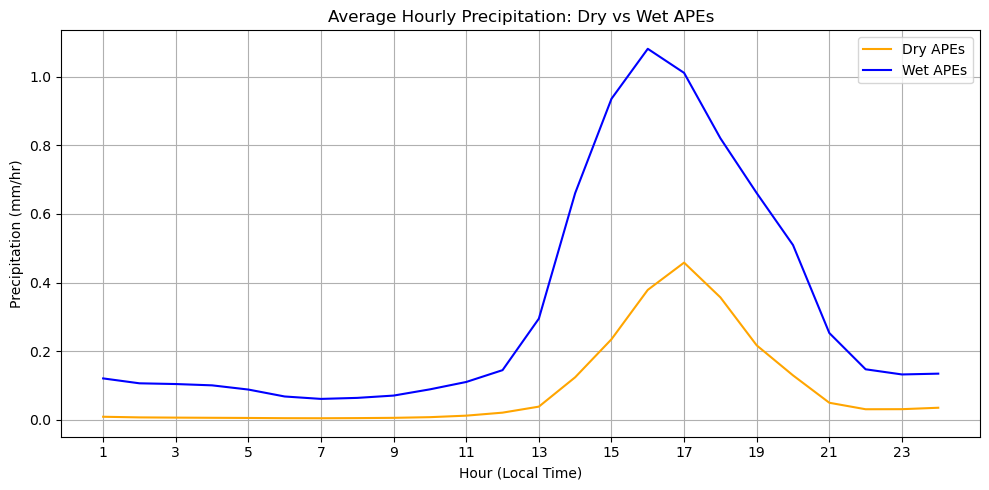

In [6]:
dry_case = master_w_sp[master_w_sp['dryape']==True]

wet_case = master_w_sp[master_w_sp['wetape']==True]

# Stack daily_precip arrays and compute the hourly average

dry_mean = np.vstack(dry_case['daily_precip'].values).mean(axis=0)

wet_mean = np.vstack(wet_case['daily_precip'].values).mean(axis=0)

# X-axis: hours 1 to 24 (if your arrays are labeled that way)
hours = np.arange(1, 25)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(hours, dry_mean, label='Dry APEs', color='orange')
plt.plot(hours, wet_mean, label='Wet APEs', color='blue')

plt.xlabel('Hour (Local Time)')
plt.ylabel('Precipitation (mm/hr)')
plt.title('Average Hourly Precipitation: Dry vs Wet APEs')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(1, 25, 2))  # every 2 hours
plt.tight_layout()
plt.show()


In [6]:
with open('/home/annierosen16/jupyter_notebooks/master_with_dqdy.pkl', 'rb') as f:
    
    dqdy = pickle.load(f)

In [8]:
merged_master = pd.merge(master_clean, dqdy, on=['date', 'latitude', 'longitude'], how='inner')

merged_master.shape, master_clean.shape, dqdy.shape

((4177818, 42), (4177818, 41), (4177818, 4))

In [160]:
with open('/home/annierosen16/pressure.pkl', 'rb') as f:
    
    pressure = pickle.load(f) * 100
    
with open('/home/annierosen16/sgp_latitudes.pkl', 'rb') as f:
    
    latitude = pickle.load(f)
    
with open('/home/annierosen16/sgp_longitudes.pkl', 'rb') as f:
    
    longitude = pickle.load(f)

In [130]:
dryapes = merged_master[merged_master['dryape']==True].reset_index(drop=True)

wetapes = merged_master[merged_master['wetape']==True]

wetapes_mini = wetapes[(wetapes['latitude'].between(30, 33)) & (wetapes['longitude'].between(-95, -92))].reset_index(drop=True)

dryapes_mini = dryapes[(dryapes['latitude'].between(30, 33)) & (dryapes['longitude'].between(-95, -92))].reset_index(drop=True)

In [181]:
def compute_mean_profile(df, column_name, pressure):
    """
    Computes the mean profile for a given column while ensuring that values BELOW ground (where pressure < average_sp) are NaN.
    
    Parameters:
    - df: DataFrame containing the data
    - column_name: Name of the column (e.g., 'mean_v_profile', 'dqdy_domain_mean')

    Returns:
    - A 1D NumPy array representing the mean profile across all rows
    """
    
    profile_array = np.stack(df[column_name].values)

    average_sp_array = df['average_sp'].values[:, None]  # Shape: (rows, 1)

    # Mask values BELOW ground (where pressure < surface pressure)
    
    mask = pressure > average_sp_array  # True for underground values
    
    profile_array[mask] = np.nan
    
    # Compute the proportion of NaNs: sum of NaNs divided by total count
    nan_count = np.sum(np.isnan(profile_array), axis=0)
    
    total_count = profile_array.shape[0]  # Number of rows
    
    nan_proportion = (nan_count / total_count) * 100  # Proportion of NaNs at each level

    # Print the proportion of NaNs for each level
    
#     print(f"Proportion of NaNs for {column_name}:")
    
#     print(nan_proportion)
    
    return np.nanmean(profile_array, axis=0)

mean_v_profile_dry = compute_mean_profile(dryapes, "mean_v_profile", pressure)

mean_v_profile_wet = compute_mean_profile(wetapes, "mean_v_profile", pressure)

dqdy_domain_mean_dry = compute_mean_profile(dryapes, "dqdy_domain_mean", pressure) * -1

dqdy_domain_mean_wet = compute_mean_profile(wetapes, "dqdy_domain_mean", pressure) * -1

In [140]:
meridional_advection_dry = np.nanmean(np.stack(dryapes["meridional_advection"].values), axis=0)

meridional_advection_wet = np.nanmean(np.stack(wetapes["meridional_advection"].values), axis=0)

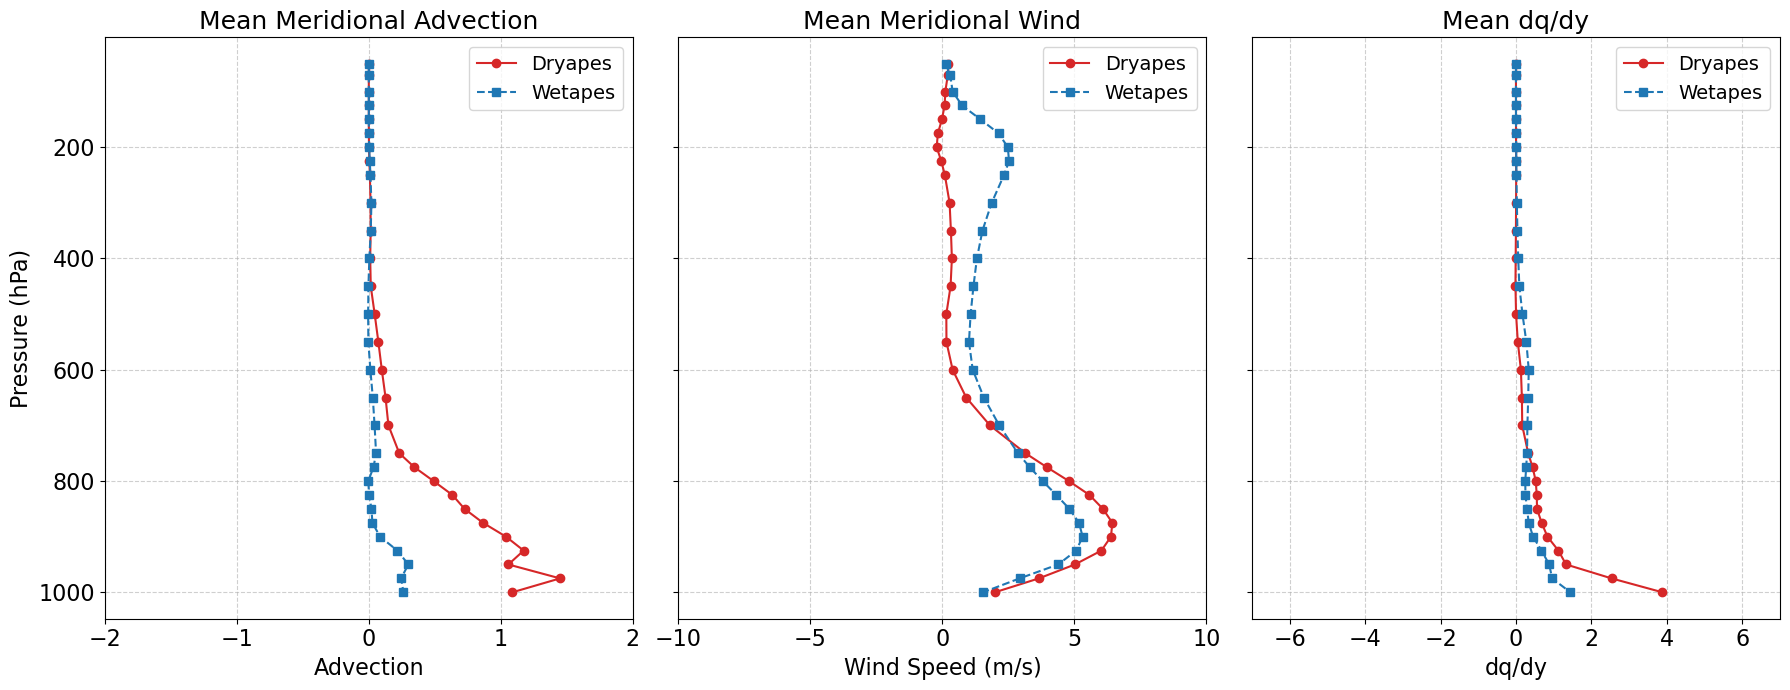

In [164]:
dry_color = "tab:red"

wet_color = "tab:blue"

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

# === Plot Mean Meridional Advection (Left Plot) ===

axes[0].plot(meridional_advection_dry, pressure/100, label="Dryapes", linestyle="-", marker="o", color=dry_color)

axes[0].plot(meridional_advection_wet, pressure/100, label="Wetapes", linestyle="--", marker="s", color=wet_color)

axes[0].invert_yaxis()  # Invert y-axis (higher altitudes on top)

axes[0].set_title("Mean Meridional Advection", fontsize=18)

axes[0].set_xlabel("Advection", fontsize=16)

axes[0].set_ylabel("Pressure (hPa)", fontsize=16)

axes[0].legend(fontsize=14)

axes[0].set_xlim(-2,2)

axes[0].grid(True, linestyle="--", alpha=0.6)

# === Plot Mean Meridional Wind (Middle Plot) ===

axes[1].plot(mean_v_profile_dry, pressure/100, label="Dryapes", linestyle="-", marker="o", color=dry_color)

axes[1].plot(mean_v_profile_wet, pressure/100, label="Wetapes", linestyle="--", marker="s", color=wet_color)

axes[1].set_title("Mean Meridional Wind", fontsize=18)

axes[1].set_xlabel("Wind Speed (m/s)", fontsize=16)

axes[1].legend(fontsize=14)

axes[1].grid(True, linestyle="--", alpha=0.6)

axes[1].set_xlim(-10, 10)

# === Plot Mean dq/dy (Right Plot) ===

axes[2].plot(dqdy_domain_mean_dry, pressure/100, label="Dryapes", linestyle="-", marker="o", color=dry_color)

axes[2].plot(dqdy_domain_mean_wet, pressure/100, label="Wetapes", linestyle="--", marker="s", color=wet_color)

axes[2].set_title("Mean dq/dy", fontsize=18)

axes[2].set_xlabel("dq/dy", fontsize=16)

axes[2].legend(fontsize=14)

axes[2].grid(True, linestyle="--", alpha=0.6)

axes[2].set_xlim(-7, 7)

# Apply consistent y-axis formatting
for ax in axes:
    
    ax.tick_params(axis="both", labelsize=16)

plt.tight_layout()

plt.show()

In [154]:
def extract_value_at_pressure(df, column_name, pressure_level):
    """
    Extracts the value at a specific pressure level from a column containing arrays,
    ensuring that values below ground (pressure < average_sp) are set to NaN.

    Parameters:
    - df: DataFrame containing the data (e.g., dryapes or wetapes)
    - column_name: Name of the column containing the arrays
    - pressure_level: The pressure level to extract from the arrays

    Returns:
    - A Pandas Series with the extracted values at the given pressure level, or NaN if below ground.
    """
    # Find the index corresponding to the desired pressure level
    target_index = np.where(pressure == pressure_level)[0]
    
    # Ensure there's exactly one valid index
    if target_index.size == 1:
        
        target_index = target_index[0]  # Convert to scalar index

        return df.apply(
            
            lambda row: (
                
                row[column_name][target_index] 
                
                if isinstance(row[column_name], np.ndarray) and 
                   row[column_name].shape[0] > target_index and 
                   row["average_sp"] >= pressure_level  # Check if value is above ground
                else np.nan
            ), axis=1
        )

    else:
        raise ValueError(f"Pressure level {pressure_level} Pa is not uniquely indexed or missing.")

# === Apply function for both Dryapes and Wetapes ===
# Extract meridional wind (mean_v_profile) at 97500 Pa

dryapes["v_875"] = extract_value_at_pressure(dryapes, "mean_v_profile", 87500)

wetapes["v_875"] = extract_value_at_pressure(wetapes, "mean_v_profile", 87500)

# Extract dqdy_domain_mean at 97500 Pa

dryapes["dqdy_975"] = extract_value_at_pressure(dryapes, "dqdy_domain_mean", 97500) * -1

wetapes["dqdy_975"] = extract_value_at_pressure(wetapes, "dqdy_domain_mean", 97500) * -1

/tmp/ipykernel_53143/2760233887.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wetapes["v_875"] = extract_value_at_pressure(wetapes, "mean_v_profile", 87500)
/tmp/ipykernel_53143/2760233887.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wetapes["dqdy_975"] = extract_value_at_pressure(wetapes, "dqdy_domain_mean", 97500) * -1


In [209]:
dryapes_filtered = dryapes[dryapes['dqdy_975'].notna()]

dryapes_sorted = dryapes_filtered.sort_values(by='dqdy_975', ascending=False)

dqdy_days = dryapes_sorted['date'].dt.date.unique().tolist()

In [237]:
dqdy_days[-1]

datetime.date(2010, 8, 1)

In [235]:
dryapes_sorted.tail()

,date,latitude,longitude,APE,daily_precip,reason_for_fail,saturation,ctp,hilow,blc,...,vertical_advection,average_sp,mean_u_profile,mean_v_profile,mean_w_profile,u_800,v_800,dqdy_domain_mean,v_875,dqdy_975
196820,2015-09-20,32.25,-96.00,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,dry,268.999908,14.683177,-103.945106,...,"[-8.335849310067509e-05, 0.0001135181747289249...",100021.849668,"[-6.795039553844821, 0.42914986365856334, 12.3...","[-0.951844402277899, -2.946971767674813, -2.98...","[0.004871102415732243, -0.005548144148086487, ...",0.155800,2.821715,"[0.0, 0.0, 0.0, -0.0008714393047943986, 0.0025...",2.773920,-18.036188
213830,2006-06-13,31.75,-96.00,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,dry,268.985240,13.468566,-103.933636,...,"[0.0, 0.00011937161073031328, 0.00046815928729...",100217.448849,"[-10.012313882008748, -6.735116751503109, 1.51...","[-1.4194996289248527, -2.1036679243381604, -11...","[-0.009339190645747451, -0.008645864238165372,...",-1.500550,-5.901025,"[0.0, 0.0, -0.00042477611533919856, 0.00084983...",-1.958529,-18.550262
205258,2006-06-13,32.00,-96.25,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,dry,228.577750,11.586226,-106.443943,...,"[-1.7737411202493893e-06, 0.000129948453374902...",100206.699605,"[-9.592799889594477, -6.822753601625277, 2.233...","[-1.4994562132487013, -2.3127723756598386, -12...","[-0.009233428990353582, -0.009245180285397362,...",-1.560216,-5.764351,"[-5.235775724601368e-05, 0.0, -0.0004770025047...",-1.669606,-21.769308
175309,2008-07-31,32.75,-98.25,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,dry,191.359598,19.176719,-257.533702,...,"[4.573755332265723e-05, -0.0002513270045946009...",97780.460732,"[-10.473335795772915, -6.1396441341270505, -3....","[-0.6368969954312339, -1.2118762555827518, -3....","[0.006029377014978698, 0.00512950558238625, -0...",5.070087,-2.882771,"[0.0017760065942229542, 0.0, -0.00039792632109...",-0.502166,-22.964055
175488,2008-07-31,32.75,-98.00,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,dry,177.730803,18.661431,-261.872941,...,"[4.5551639114002265e-05, -0.000269826868633531...",97924.862339,"[-10.481160290670214, -6.2834033674023235, -3....","[-0.6053967970454771, -1.2778455208922204, -3....","[0.004980983112929244, 0.005535758219430444, -...",5.491531,-1.993393,"[0.0014913523535864147, 0.0, -0.00062746452065...",0.106704,-23.491908


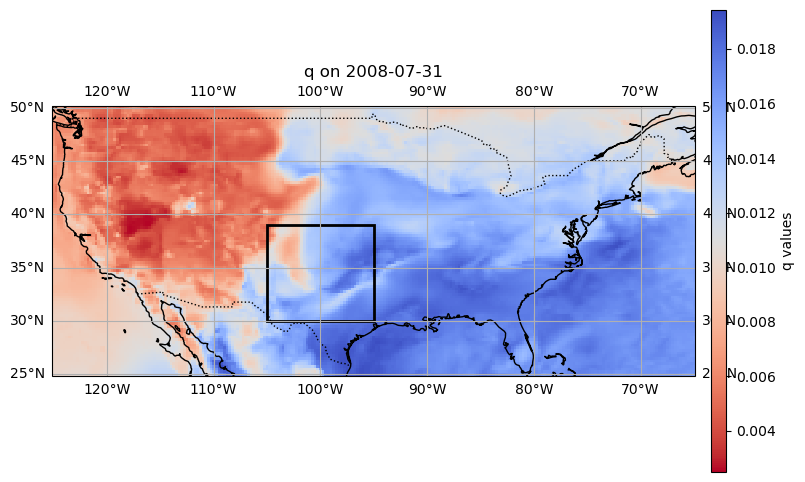

In [238]:
# test_date = pd.to_datetime(dqdy_days[]).date()

test_date = pd.to_datetime("2008-07-31").date()

qsub6['date'] = qsub6['time'].dt.date  

matching_time_idx = qsub6['date'] == test_date

q_on_test_date = qsub6.sel(time=qsub6['time'][matching_time_idx]).isel(time=0)

q_on_test_date = q_on_test_date.sel(level=975)

lons = q_on_test_date['longitude']

lats = q_on_test_date['latitude']

q_values = q_on_test_date['q']

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the data using pcolormesh
mesh = ax.pcolormesh(lons, lats, q_values, cmap='coolwarm_r', transform=ccrs.PlateCarree())

ax.coastlines()

ax.add_feature(cfeature.BORDERS, linestyle=':')

ax.gridlines(draw_labels=True)

# Add colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, aspect=30)

cbar.set_label('q values')

# Add title
ax.set_title(f"q on {test_date}")

sgp_lon_min, sgp_lon_max = -105, -95

sgp_lat_min, sgp_lat_max = 30, 39

box = Rectangle((sgp_lon_min, sgp_lat_min), sgp_lon_max - sgp_lon_min, sgp_lat_max - sgp_lat_min,
                linewidth=2, edgecolor='black', facecolor='none', transform=ccrs.PlateCarree())

ax.add_patch(box)

plt.show()

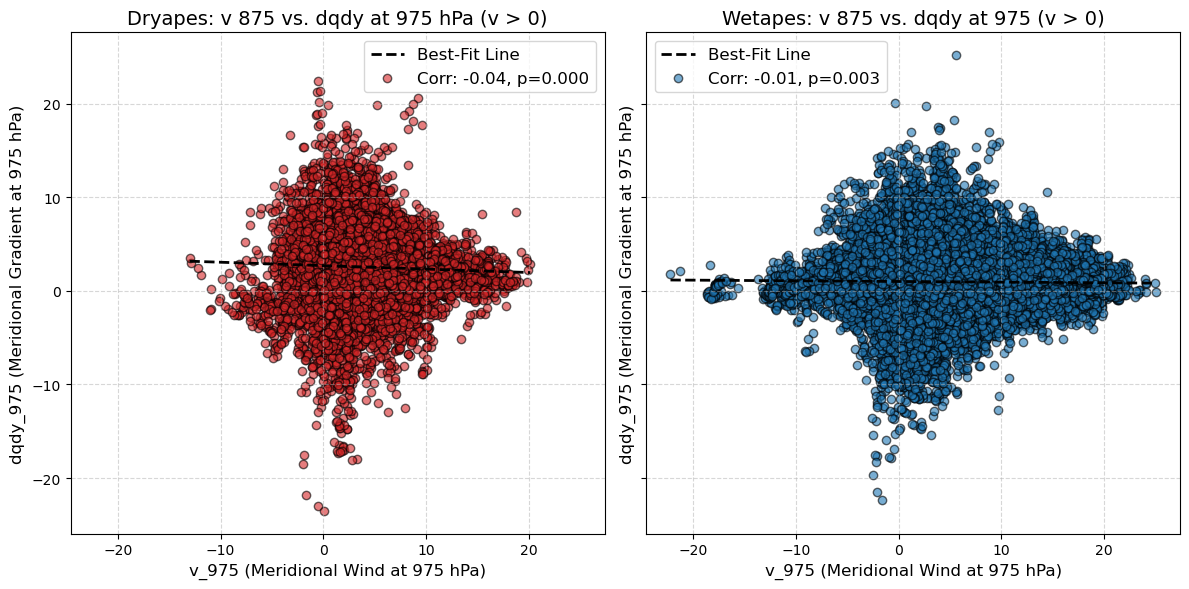

In [150]:
def plot_scatter_with_fit(ax, x, y, color, title, label):
    """
    Plots a best-fit regression line first, then scatter points to ensure visibility.
    
    Parameters:
    - ax: Matplotlib axis to plot on
    - x, y: Data for scatter plot
    - color: Color of scatter points
    - title: Plot title
    - label: Correlation and p-value label
    """
    # Compute best-fit line
    if len(x) > 1:  # Ensure there's enough data to fit
        slope, intercept = np.polyfit(x, y, 1)  # Linear regression (y = mx + b)
        x_fit = np.linspace(min(x), max(x), 100)  # Generate x values for the line
        y_fit = slope * x_fit + intercept  # Compute corresponding y values
        ax.plot(x_fit, y_fit, color="black", linestyle="--", linewidth=2, label="Best-Fit Line")  # Plot line

    # Scatter plot (plotted AFTER the regression line)
    ax.scatter(x, y, color=color, edgecolors="black", alpha=0.6, label=label)

    # Formatting
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("v_975 (Meridional Wind at 975 hPa)", fontsize=12)
    ax.set_ylabel("dqdy_975 (Meridional Gradient at 975 hPa)", fontsize=12)
    ax.legend(fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.5)

# === Condition Data on v_975 > 0 ===

# Dryapes: Select only rows where v_875 > 0

dry_filtered = dryapes[["v_875", "dqdy_975"]].dropna()

dry_x = dry_filtered["v_875"]

dry_y = dry_filtered["dqdy_975"]

# Wetapes: Select only rows where v_875 > 0

wet_filtered = wetapes[["v_875", "dqdy_975"]].dropna()

wet_x = wet_filtered["v_875"]

wet_y = wet_filtered["dqdy_975"]

# Compute correlation & p-value for the filtered data

corr_dry, p_dry = pearsonr(dry_x, dry_y) if len(dry_x) > 1 else (np.nan, np.nan)

corr_wet, p_wet = pearsonr(wet_x, wet_y) if len(wet_x) > 1 else (np.nan, np.nan)

# Create figure with two subplots side by side

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# === Plot Dryapes ===
plot_scatter_with_fit(axes[0], dry_x, dry_y, "tab:red", 
                      "Dryapes: v 875 vs. dqdy at 975 hPa (v > 0)", f"Corr: {corr_dry:.2f}, p={p_dry:.3f}")

# === Plot Wetapes ===
plot_scatter_with_fit(axes[1], wet_x, wet_y, "tab:blue", 
                      "Wetapes: v 875 vs. dqdy at 975 (v > 0)", f"Corr: {corr_wet:.2f}, p={p_wet:.3f}")

# Improve layout

plt.tight_layout()

plt.show()
